# Saving and Loading LOFAR Cutouts with strw_lofar_data_utils

This notebook demonstrates a complete cutout workflow on the STRW cluster:
- Load a source catalogue and extract RA/Dec positions
- Generate DR3 cutouts from those sky coordinates
- Inspect a representative cutout with contour overlays
- Save a cutout to FITS with STRW reconstruction metadata
- Recreate a Cutout object from the saved FITS metadata

## 1) Imports
Import the core tools used for catalogue handling, cutout generation, and visualization.

In [1]:
import pandas as pd
import os

from strw_lofar_data_utils.pipelines import generate_cutouts
from strw_lofar_data_utils.core.vizualization import Vizualizer

## 2) Load the Catalogue
Load the giant radio galaxy catalogue that provides RA/Dec positions for cutout creation.

In [2]:
GIANTS_CATALOG = "/home/penchev/strw_lofar_data_utils/data/GGO_catalogue_2025_11.csv"
GIANTS_CATALOG

'/home/penchev/strw_lofar_data_utils/data/GGO_catalogue_2025_11.csv'

In [3]:
giants_df = pd.read_csv(GIANTS_CATALOG)
giants_df.head()

,radio_name,host_name,RAJ2000,DEJ2000,z,e_z,LengthMpc,e_LengthMpc,FirstDisc,DateDisc,Ref
0,ILTJ000012.37+291113.0,NaN,0.051519,29.187479,1.47800,0.42700,0.700,0.067,Mostert & Oei et al. 2024,2024-02-23,Mostert & Oei et al. 2024
1,NaN,J000021.05+205657.5,0.087721,20.949331,0.27101,0.00003,1.618,0.026,Oei et al. 2022,2022-10-24,Oei et al. 2022
2,ILTJ000043.29+193258.8,NaN,0.181462,19.551216,1.07500,0.10600,1.406,0.057,Hardcastle et al. 2023,2023-08-29,Mostert & Oei et al. 2024
3,NaN,J000043.82+121608.3,0.182583,12.268975,0.22400,0.01130,2.125,0.086,Dabhade et al. 2020 / prior,2020-08-05,Dabhade et al. 2020 / prior
4,ILTJ000050.07+281125.4,NaN,0.206601,28.197147,0.52600,0.05000,0.990,0.063,Hardcastle et al. 2023,2023-08-29,Mostert & Oei et al. 2024


## 3) Build Sky Positions
Extract RA/Dec pairs from the catalogue to define the cutout centers.

In [4]:
# Get RA and DEC for the first 100 giants
ra_dec_list = list(
    zip(giants_df["RAJ2000"].values, giants_df["DEJ2000"].values)
)
ra_dec_list[:10]

[(0.051519, 29.187479),
 (0.087721, 20.949331),
 (0.181462, 19.551216),
 (0.182583, 12.268975),
 (0.206601, 28.197147),
 (0.239319, 26.623834),
 (0.266126, 27.582283),
 (0.273409, 34.465758),
 (0.28152, 23.87971),
 (0.3713, 32.250189)]

## 4) Generate DR3 Cutouts
Create cutouts for the selected positions. In this example, cutouts are kept in memory (`save=False`) so we can inspect them first.

In [5]:
dr3_cutouts = generate_cutouts(
    ra_dec_list=ra_dec_list[:100],
    size_pixels = 300,
    save=False,
    release='DR3'
)

In [6]:
print(f"Number of DR3 cutouts: {len(dr3_cutouts)}")

Number of DR3 cutouts: 91


Some requested coordinates do not return valid cutouts. Typical reasons are:
- The position is outside DR3 mosaic coverage
- The position is near a mosaic edge and fails the valid data-region check

So the number of generated cutouts can be smaller than the number of requested coordinates.

## 5) Visualize a Sample Cutout
Inspect one generated DR3 cutout with contour overlays before saving.

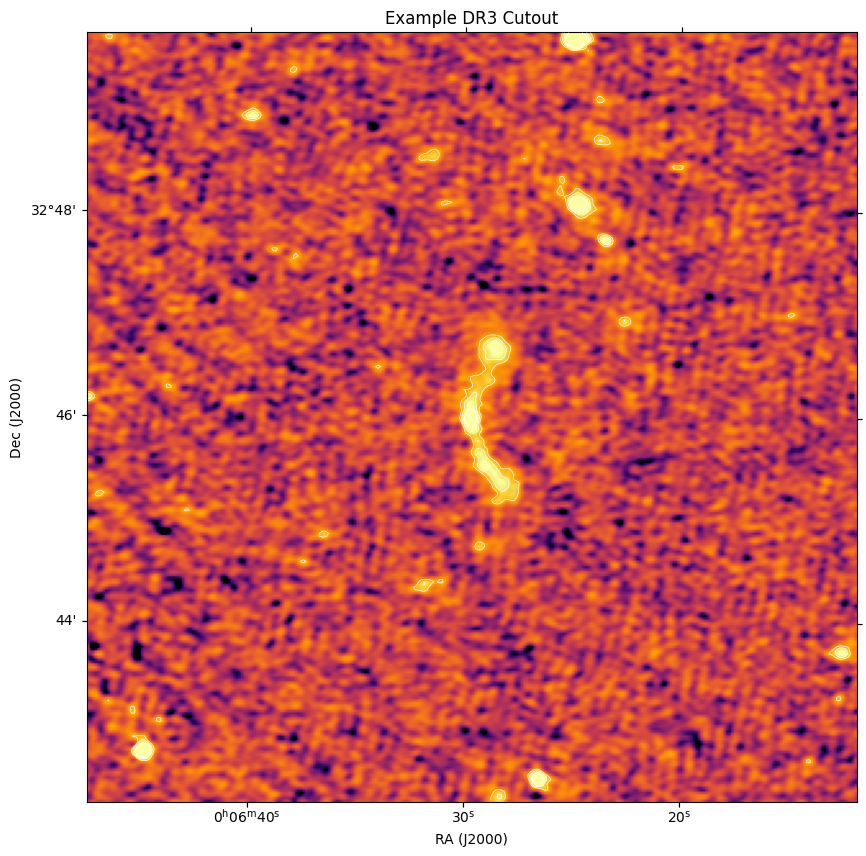

In [7]:
example_cutout = dr3_cutouts[23]

Vizualizer().vizualize_a_cutout(
    cutout=example_cutout,
    title="Example DR3 Cutout",
    contour_levels=[3, 5, 10]
)

## 6) Save a Cutout to FITS
Write the cutout to disk. The FITS header includes STRW metadata needed to reconstruct the `Cutout` object later.

In [8]:
# Save the cutouts to disk
output_dir = "/home/penchev/strw_lofar_data_utils/data/cutouts"
output_path = example_cutout.save_cutout(
    output_dir,
    filename=None # This will generate a filename based on the cutout's RA and DEC
)

## 7) Reload the Cutout from FITS Metadata
Recreate a `Cutout` instance from the saved FITS file and verify it can be visualized identically.

In [9]:
from strw_lofar_data_utils.core.cutout_maker import Cutout

loaded_cutout = Cutout.from_saved_fits(output_path)

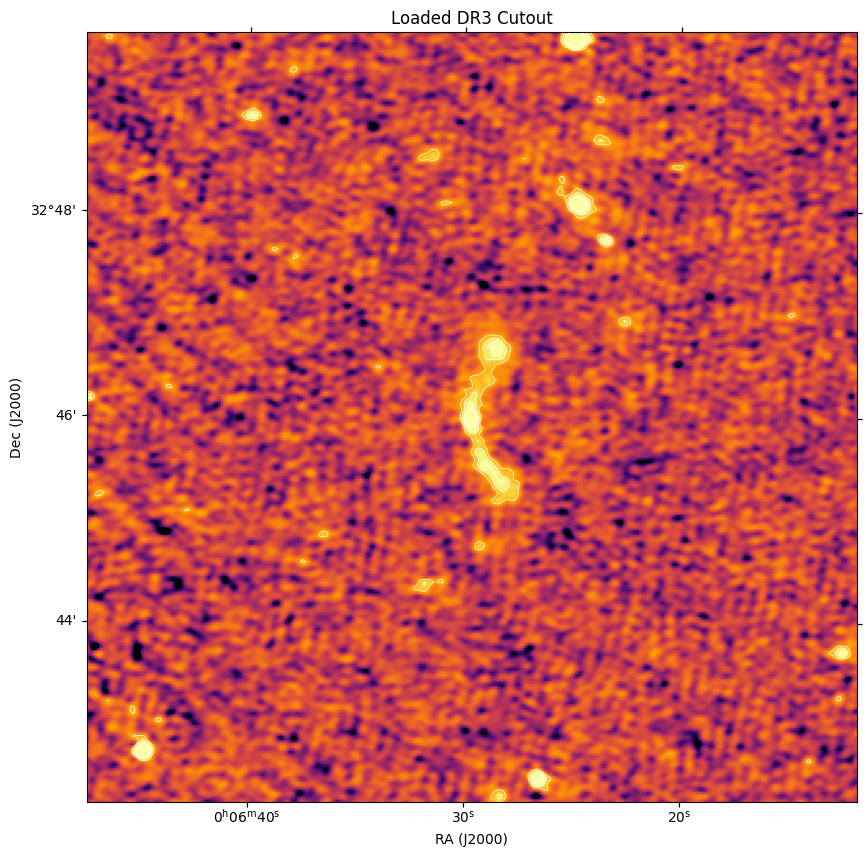

In [10]:
Vizualizer().vizualize_a_cutout(
    cutout=loaded_cutout,
    title="Loaded DR3 Cutout",
    contour_levels=[3, 5, 10]
)